# Mochila múltiple con condiciones negadas, de la simulación al hardware IBM

Este notebook resuelve una **mochila múltiple** (varios objetos, varias mochilas, cada una con su capacidad) con la técnica del paper *Negation-forced amplitude amplification*. El recorrido es:

1. Traducir **todas** las reglas del problema a *condiciones negadas*, es decir, patrones prohibidos.
2. Construir la preparación $A_\pi$: cada variable recibe un Hadamard **solo si ninguna regla la fuerza**.
3. Verificar con simulación ideal, predecir el resultado en hardware con el modelo de ruido de `ibm_fez`, y **ejecutarlo en hardware real** (celda con `RUN_HARDWARE = True`).
4. Escalar a una instancia de 18 variables en simulación y buscar el óptimo subiendo el umbral de valor.

**Qué esperar, con honestidad.** Hoy el hardware tiene ruido, así que el experimento útil es la preparación $A_\pi$ sola, sin iteraciones de Grover. La prueba consiste en ver que la frecuencia del óptimo queda **muy por encima** de muestrear al azar. Instancias tan pequeñas se resuelven al instante en una computadora clásica; el objetivo es demostrar el mecanismo.

> Requiere la carpeta `negsearch/` del repositorio (este notebook está en `notebooks/`).

In [1]:
import sys, itertools, random, math, json, time
sys.path.insert(0, '..')                       # carpeta del repositorio con negsearch/
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from negsearch.core import CNF, enumerate_models, success_by_solutions, amplification_iterations, amplified_success
from negsearch.circuits import NegForcedSearch, for_simulation

## 1. El problema

Tenemos 4 objetos (peso, valor) y 2 mochilas con capacidades 6 y 5. Cada objeto va en **a lo más una** mochila. Buscamos una asignación con valor total $\ge V$; subiendo $V$ se llega al óptimo.

Variables: $x_{i,k}=1$ si el objeto $i$ va en la mochila $k$, en total $4\times2=8$ qubits de búsqueda.

In [2]:
w = [3, 4, 2, 5]          # pesos
v = [4, 5, 3, 6]          # valores
caps = [6, 5]             # capacidades
I, K = len(w), len(caps)
var = lambda i, k: i*K + k + 1     # variable (1-indexada) del par objeto-mochila

def brute_force(w, v, caps, V):
    I, K = len(w), len(caps); sols = []
    for a in itertools.product(range(K+1), repeat=I):          # 0 = fuera, k+1 = mochila k
        if all(sum(w[i] for i in range(I) if a[i]==k+1) <= caps[k] for k in range(K)) and \
           sum(v[i] for i in range(I) if a[i] > 0) >= V:
            sols.append(a)
    return sols

best_value = max(sum(v[i] for i in range(I) if a[i] > 0) for a in brute_force(w, v, caps, 0))
print('valor óptimo (fuerza bruta):', best_value)
for a in brute_force(w, v, caps, best_value):
    print('  asignación óptima:', {f'obj{i}': ('fuera' if a[i]==0 else f'mochila {a[i]-1}') for i in range(I)})

valor óptimo (fuerza bruta): 14
  asignación óptima: {'obj0': 'fuera', 'obj1': 'mochila 0', 'obj2': 'mochila 0', 'obj3': 'mochila 1'}


## 2. Las reglas como condiciones negadas

Cada regla se escribe como **lo que no puede pasar**, y su negación es una cláusula:

| Regla | Patrón prohibido | Cláusula (su negación) |
|---|---|---|
| Un objeto, una mochila | $x_{i,1}\wedge x_{i,2}$ | $\neg x_{i,1}\vee\neg x_{i,2}$ |
| Capacidad de la mochila $k$ | todos los objetos de una **cobertura mínima** $S$ (subconjunto que se pasa de la capacidad) | $\bigvee_{i\in S}\neg x_{i,k}$ |
| Valor $\ge V$ | elegir solo objetos de un conjunto **insuficiente maximal** $U$ | $\bigvee_{j\notin U,\,k} x_{j,k}$ |

Dentro del circuito, una cláusula *fuerza* una variable en cuanto todos sus otros literales son falsos. Por ejemplo, si la mochila ya tiene un objeto pesado, el siguiente objeto pesado queda forzado a 0 sin gastar una decisión.

In [3]:
def mkp_cnf(w, v, caps, V):
    I, K = len(w), len(caps); cls = []
    for i in range(I):
        for k1, k2 in itertools.combinations(range(K), 2):
            cls.append((-var(i,k1), -var(i,k2)))
    for k, Cap in enumerate(caps):
        for r in range(1, I+1):
            for S in itertools.combinations(range(I), r):
                if sum(w[i] for i in S) > Cap and all(sum(w[j] for j in S if j != i) <= Cap for i in S):
                    cls.append(tuple(-var(i,k) for i in S))
    for r in range(I+1):
        for U in itertools.combinations(range(I), r):
            if sum(v[i] for i in U) < V and all(sum(v[i] for i in U) + v[j] >= V for j in range(I) if j not in U):
                cls.append(tuple(var(j,k) for j in range(I) if j not in U for k in range(K)))
    return CNF(I*K, cls, 'MKP', dict(V=V))

V = best_value
F = mkp_cnf(w, v, caps, V)
sols = enumerate_models(F)
print(f'{F.n} variables, {F.m} cláusulas; soluciones CNF = {len(sols)}, fuerza bruta = {len(brute_force(w, v, caps, V))}')
for c in F.clauses: print('  ', c)

8 variables, 16 cláusulas; soluciones CNF = 1, fuerza bruta = 1
   (-1, -2)
   (-3, -4)
   (-5, -6)
   (-7, -8)
   (-1, -3)
   (-1, -7)
   (-3, -7)
   (-5, -7)
   (-2, -4)
   (-2, -8)
   (-4, -6)
   (-4, -8)
   (-6, -8)
   (1, 2, 5, 6)
   (7, 8)
   (3, 4)


## 3. Preparación con condiciones negadas y su probabilidad exacta

Por el Lema 2 del paper, $p_\pi=\sum_{a\in\text{Sol}}2^{-D_\pi(a)}$, donde $D_\pi(a)$ es el número de variables **no forzadas** (decisiones) en el camino hacia la solución $a$. Se calcula de forma clásica y barata, así que podemos **elegir el mejor orden** $\pi$ antes de usar el computador cuántico.

In [4]:
rng = random.Random(1)
p_uniform = len(sols) / 2**F.n
best = None
for _ in range(300):
    o = list(range(1, F.n+1)); rng.shuffle(o)
    p, D = success_by_solutions(F, o, sols)
    if best is None or p > best[0]: best = (p, o, D)
p_nf, order, D = best
print(f'p (superposición uniforme, Grover) = {p_uniform:.4f}')
print(f'p (condiciones negadas)            = {p_nf:.4f}   -> {p_nf/p_uniform:.0f}x mayor')
print(f'decisiones en el camino a la solución: {D} de {F.n} variables')
print(f'iteraciones de amplificación: Grover k*={amplification_iterations(p_uniform)}, negadas k*={amplification_iterations(p_nf)}')

p (superposición uniforme, Grover) = 0.0039
p (condiciones negadas)            = 0.5000   -> 128x mayor
decisiones en el camino a la solución: [1] de 8 variables
iteraciones de amplificación: Grover k*=12, negadas k*=0


## 4. El circuito y su costo en `ibm_fez`

qubits lógicos: 16 | CZ en ibm_fez: 695 | profundidad: 1422


con k=1 iteraciones de amplificación: CZ = 5048  (demasiado profundo para el hardware actual)


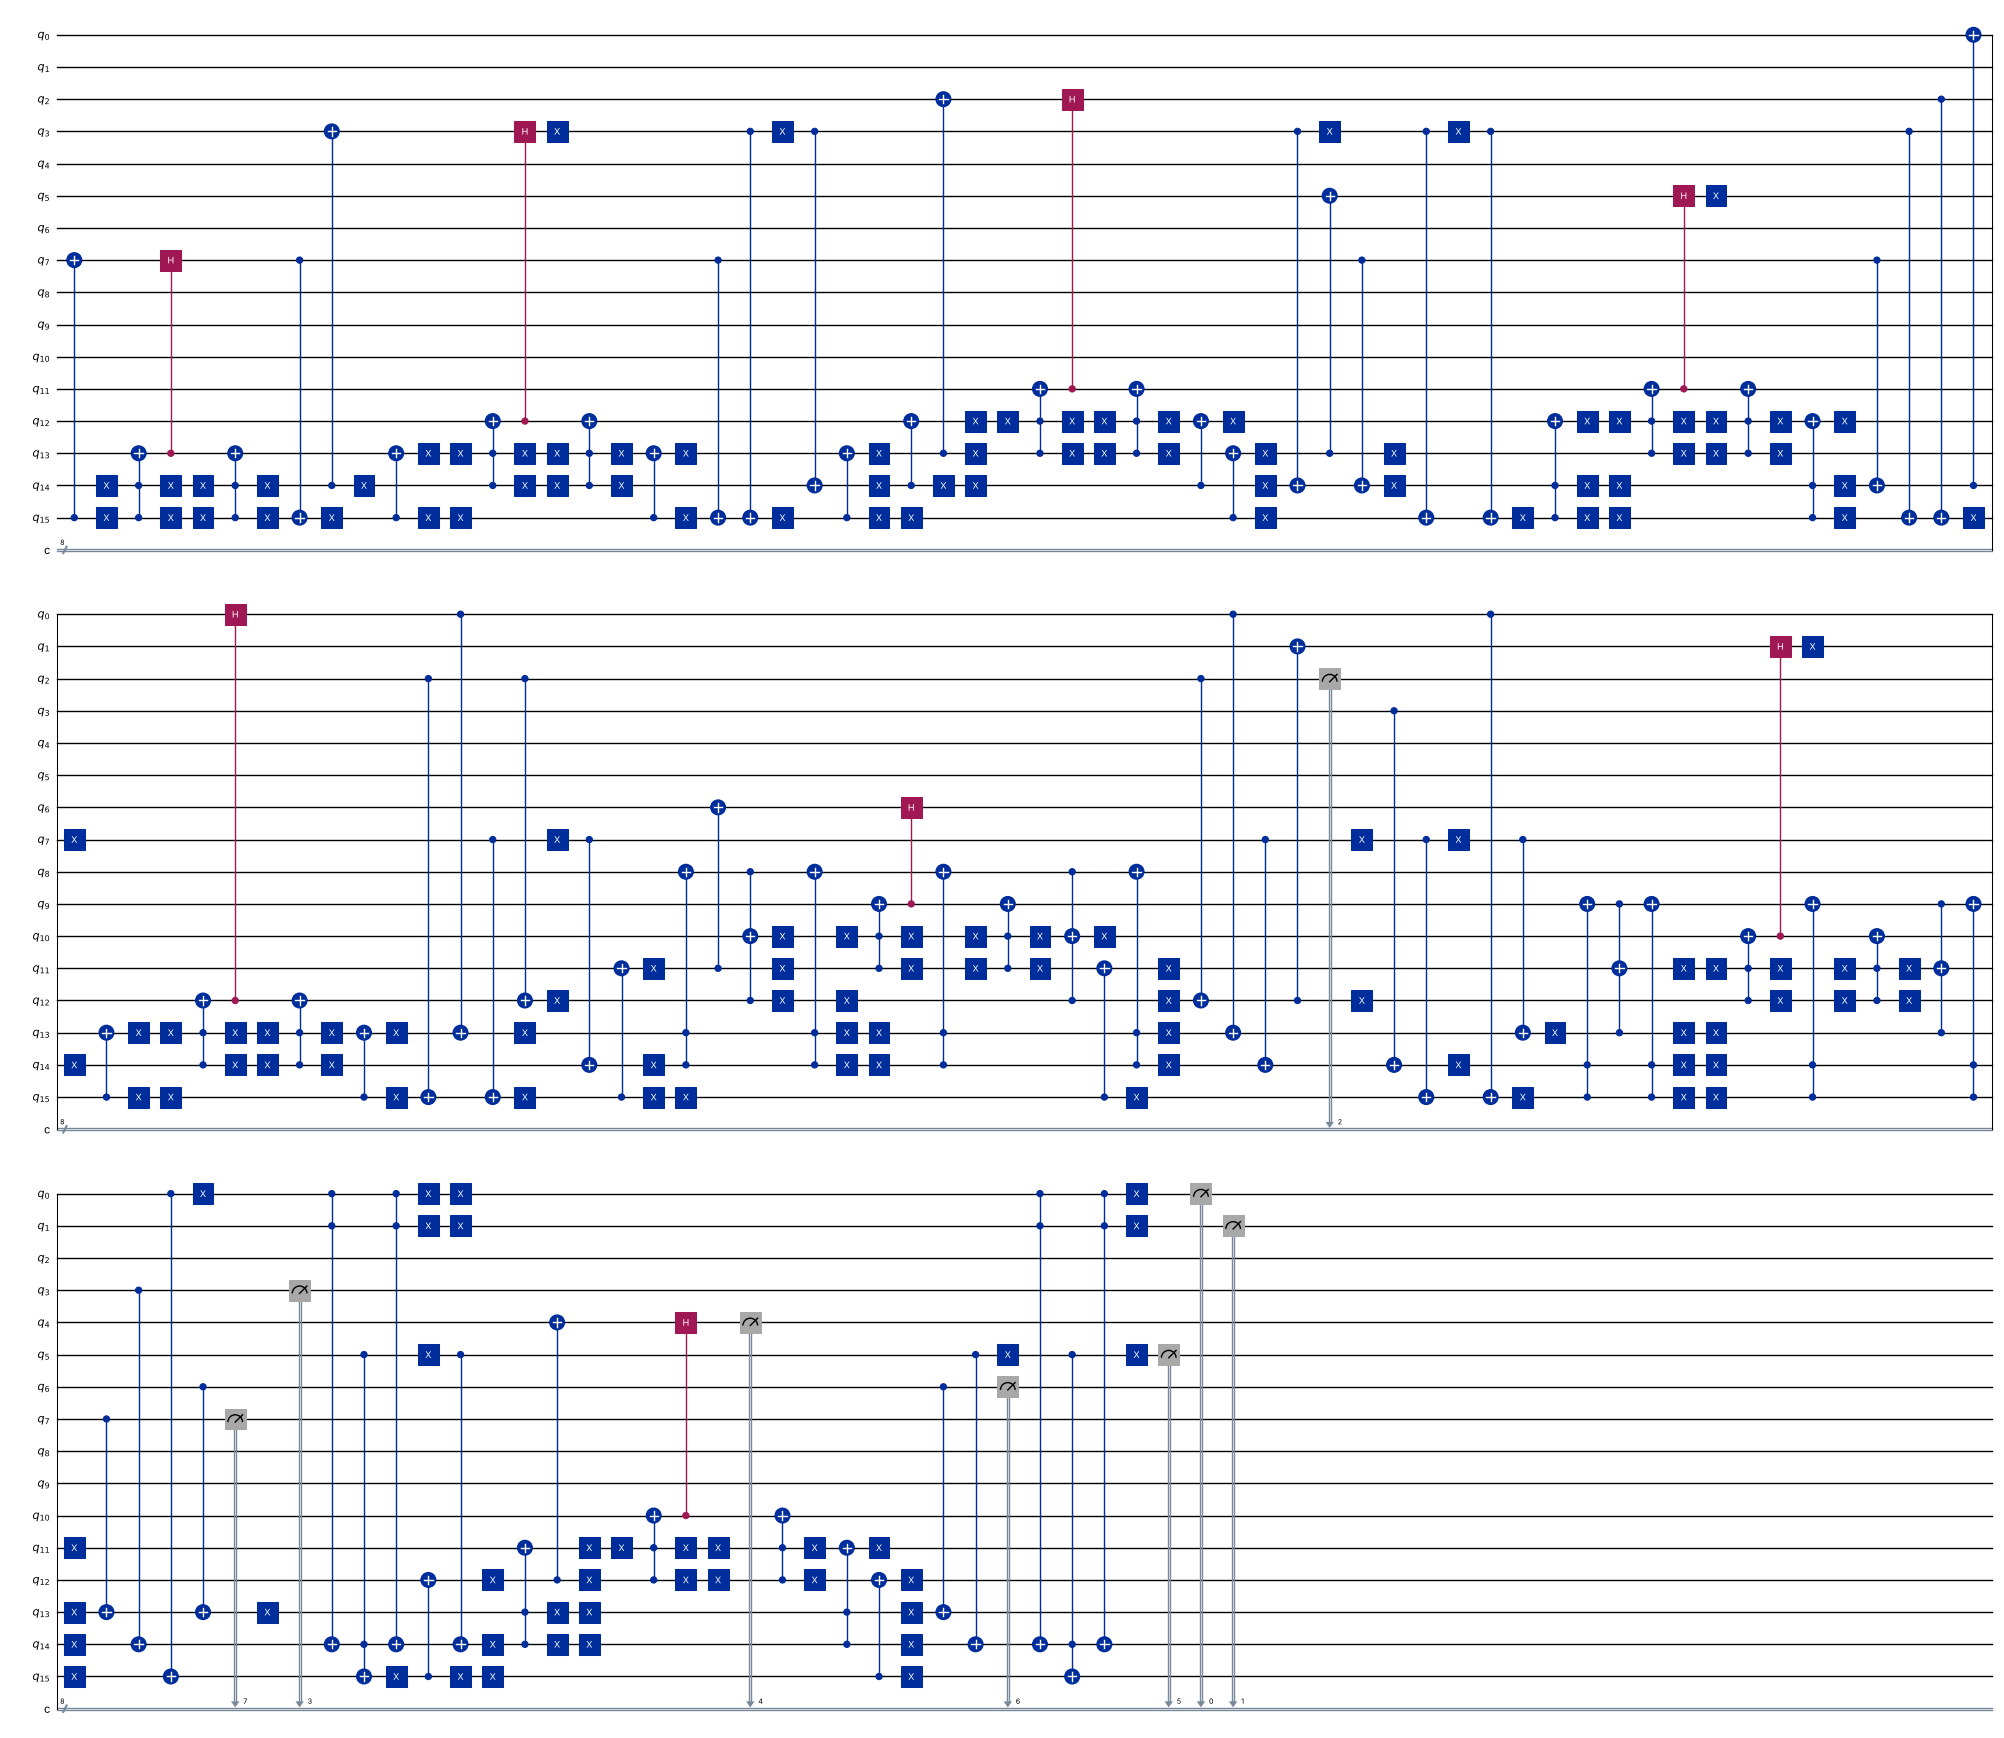

In [5]:
def prep_circuit(F, order, k=0, baseline=False):
    b = NegForcedSearch(F, order, baseline=baseline)
    qc = b.amplified(k, measure=False)
    used = sorted({qc.find_bit(q).index for inst in qc.data for q in inst.qubits} | set(range(F.n)))
    m = {qc.qubits[u]: j for j, u in enumerate(used)}
    out = QuantumCircuit(len(used), F.n)
    for inst in qc.data:
        out.append(inst.operation, [out.qubits[m[q]] for q in inst.qubits])
    out.measure(range(F.n), range(F.n))
    return out

qc_prep = prep_circuit(F, order, k=0)
from qiskit_ibm_runtime.fake_provider import FakeFez
fake = FakeFez()
isa_fake = transpile(qc_prep, fake, optimization_level=3, seed_transpiler=3)
print('qubits lógicos:', qc_prep.num_qubits, '| CZ en ibm_fez:', isa_fake.count_ops().get('cz', 0), '| profundidad:', isa_fake.depth())
for k in (1,):
    t = transpile(prep_circuit(F, order, k=k), fake, optimization_level=3, seed_transpiler=3)
    print(f'con k={k} iteraciones de amplificación: CZ = {t.count_ops().get("cz",0)}  (demasiado profundo para el hardware actual)')
qc_prep.draw('mpl', fold=60, scale=0.5)

### Cómo leer los resultados

Cada medición es una asignación candidata que **se verifica de forma clásica**, porque el algoritmo es Las Vegas: nunca acepta una respuesta falsa. Medimos tres cosas:
- $P(\text{óptimo})$: fracción de mediciones que son la asignación óptima;
- la fracción de mediciones **factibles** (cumplen las capacidades);
- el **mejor valor** encontrado, comparado con muestrear al azar el mismo número de veces.

In [6]:
def decode(bits):
    x = [int(c) for c in bits[::-1]]
    return tuple(next((k+1 for k in range(K) if x[var(i,k)-1]), 0) for i in range(I)), x

def feasible_value(bits):
    a, x = decode(bits)
    if any(x[var(i,0)-1] + x[var(i,1)-1] > 1 for i in range(I)): return None
    if any(sum(w[i] for i in range(I) if a[i]==k+1) > caps[k] for k in range(K)): return None
    return sum(v[i] for i in range(I) if a[i] > 0)

def analyze(counts, label):
    S = sum(counts.values())
    p_opt = sum(c for b, c in counts.items() if F.check_bitstring(b)) / S
    feas = sum(c for b, c in counts.items() if feasible_value(b) is not None) / S
    best_v = max((feasible_value(b) for b in counts if feasible_value(b) is not None), default=None)
    print(f'{label:28s} P(óptimo)={p_opt:.3f}  (azar: {p_uniform:.4f}, x{p_opt/p_uniform:.0f})   factibles={feas:.2f}   mejor valor={best_v}')
    return p_opt

rng_cl = np.random.default_rng(0)
rand_counts = {}
for _ in range(4000):
    b = ''.join(str(x) for x in rng_cl.integers(0, 2, F.n)); rand_counts[b] = rand_counts.get(b, 0) + 1
_ = analyze(rand_counts, 'Clásico: azar uniforme')

Clásico: azar uniforme       P(óptimo)=0.004  (azar: 0.0039, x1)   factibles=0.12   mejor valor=14


## 5. Simulación ideal

In [7]:
ideal = AerSimulator()
counts_ideal = ideal.run(for_simulation(qc_prep), shots=4000, seed_simulator=7).result().get_counts()
p_ideal = analyze(counts_ideal, 'Ideal: A_pi (k=0)')
print('teoría (Lema 2):', p_nf)

Ideal: A_pi (k=0)            P(óptimo)=0.499  (azar: 0.0039, x128)   factibles=0.50   mejor valor=14
teoría (Lema 2): 0.5


## 6. Predicción en hardware: modelo de ruido de `ibm_fez`

Esta celda tarda unos minutos (simulación ruidosa por trayectorias de 16 qubits).

In [8]:
noisy = AerSimulator.from_backend(fake)
t0 = time.time()
counts_noisy = noisy.run(isa_fake, shots=400, seed_simulator=5).result().get_counts()
p_noisy = analyze(counts_noisy, 'Ruido FakeFez: A_pi (k=0)')
print(f'({time.time()-t0:.0f} s)')

Ruido FakeFez: A_pi (k=0)    P(óptimo)=0.107  (azar: 0.0039, x28)   factibles=0.27   mejor valor=14
(489 s)


## 7. Hardware real de IBM

Pon `RUN_HARDWARE = True` y la ruta a tu archivo de API key, igual que en tus notebooks anteriores. Se activan el desacoplamiento dinámico y el *twirling* de compuertas para reducir errores coherentes. Si el job queda en cola, guarda el `job_id` y recupéralo después con `service.job(job_id)`.

In [9]:
RUN_HARDWARE = False                     # <- cambiar a True para ejecutar en IBM
API_KEY_FILE = 'apikey_personal.json'    # {"apikey": "..."}
JOB_ID = None                            # o pega aquí un job_id para recuperar resultados

if RUN_HARDWARE or JOB_ID:
    from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
    token = json.load(open(API_KEY_FILE))['apikey']
    service = QiskitRuntimeService(channel='ibm_cloud', token=token)
    if JOB_ID:
        job = service.job(JOB_ID)
    else:
        backend = service.least_busy(operational=True, simulator=False, min_num_qubits=20)
        print('backend:', backend.name)
        isa = transpile(qc_prep, backend, optimization_level=3, seed_transpiler=3)
        print('CZ:', isa.count_ops().get('cz', 0), 'profundidad:', isa.depth())
        sampler = Sampler(mode=backend)
        sampler.options.dynamical_decoupling.enable = True
        sampler.options.dynamical_decoupling.sequence_type = 'XpXm'
        sampler.options.twirling.enable_gates = True
        sampler.options.twirling.num_randomizations = 'auto'
        job = sampler.run([isa], shots=8000)
        print('job_id:', job.job_id())
    counts_hw = job.result()[0].data.c.get_counts()
    p_hw = analyze(counts_hw, f'Hardware IBM')
else:
    print('Hardware desactivado: cambia RUN_HARDWARE = True para ejecutar.')

Hardware desactivado: cambia RUN_HARDWARE = True para ejecutar.


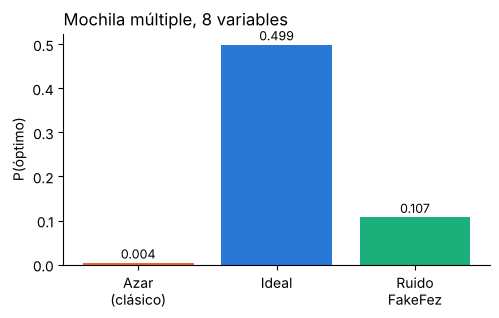

In [10]:
labels = ['Azar\n(clásico)', 'Ideal', 'Ruido\nFakeFez'] + (['Hardware'] if 'p_hw' in globals() else [])
vals = [p_uniform, p_ideal, p_noisy] + ([p_hw] if 'p_hw' in globals() else [])
fig, ax = plt.subplots(figsize=(5.5, 3))
ax.bar(labels, vals, color=['#eb6834', '#2a78d6', '#1baf7a', '#4a3aa7'][:len(vals)])
for i, y in enumerate(vals): ax.text(i, y + 0.01, f'{y:.3f}', ha='center', fontsize=9)
ax.set_ylabel('P(óptimo)'); ax.set_title('Mochila múltiple, 8 variables', loc='left')
ax.spines[['top', 'right']].set_visible(False); plt.show()

## 8. Escalar: 6 objetos y 3 mochilas (18 variables)

Con más reglas hay más condiciones negadas que fuerzan variables. Simulamos con MPS la preparación sola y la amplificación completa.

In [11]:
w, v, caps = [4, 3, 5, 2, 6, 3], [6, 4, 7, 3, 8, 4], [7, 6, 8]
I, K = len(w), len(caps)
var = lambda i, k: i*K + k + 1
opt2 = max(sum(v[i] for i in range(I) if a[i] > 0) for a in brute_force(w, v, caps, 0))
F2 = mkp_cnf(w, v, caps, opt2); sols2 = enumerate_models(F2)
rng = random.Random(2); best2 = None
for _ in range(300):
    o = list(range(1, F2.n+1)); rng.shuffle(o); p, _ = success_by_solutions(F2, o, sols2)
    if best2 is None or p > best2[0]: best2 = (p, o)
p2, order2 = best2; pu2 = len(sols2) / 2**F2.n
k2, kG = amplification_iterations(p2), amplification_iterations(pu2)
print(f'óptimo={opt2}, {F2.n} variables, {F2.m} cláusulas, {len(sols2)} soluciones óptimas')
print(f'p uniforme = {pu2:.2e} (Grover necesita k*={kG})   p negadas = {p2:.3f} (k*={k2})')

mps = AerSimulator(method='matrix_product_state')
for k in (0, k2):
    qc = NegForcedSearch(F2, order2).amplified(k)
    t0 = time.time(); cnt = mps.run(for_simulation(qc), shots=1000, seed_simulator=3).result().get_counts()
    ps = sum(c for b, c in cnt.items() if F2.check_bitstring(b)) / 1000
    print(f'k={k}: P(óptimo) MPS = {ps:.3f}   teoría = {amplified_success(p2, k):.3f}   qubits={qc.num_qubits}  ({time.time()-t0:.0f} s)')
t = transpile(prep_circuit(F2, order2, 0), fake, optimization_level=3, seed_transpiler=3)
print('CZ de la preparación sola en ibm_fez:', t.count_ops().get('cz', 0))

óptimo=29, 18 variables, 58 cláusulas, 2 soluciones óptimas
p uniforme = 7.63e-06 (Grover necesita k*=284)   p negadas = 0.094 (k*=2)


k=0: P(óptimo) MPS = 0.096   teoría = 0.094   qubits=137  (2 s)


k=2: P(óptimo) MPS = 0.999   teoría = 1.000   qubits=137  (32 s)


CZ de la preparación sola en ibm_fez: 4011


## 9. Encontrar el óptimo sin conocerlo: subir el umbral

Fuera del computador cuántico, un ciclo clásico sube $V$: se ejecuta $A_\pi$ (simulación ideal, 200 mediciones), se toma el mejor valor **verificado** y se pide $V=\text{mejor}+1$. Cuando ya no aparecen soluciones, el último valor es el óptimo. Como el algoritmo es Las Vegas, la certeza de que *no existe* algo mejor no la da el muestreo, sino la verificación clásica (aquí, por enumeración).

In [12]:
def value_of(bits, F_, w, v, caps):
    x = [int(c) for c in bits[::-1]]; I, K = len(w), len(caps)
    a = [next((k for k in range(K) if x[i*K+k]), None) for i in range(I)]
    if any(sum(x[i*K:(i+1)*K]) > 1 for i in range(I)): return None
    if any(sum(w[i] for i in range(I) if a[i]==k) > caps[k] for k in range(K)): return None
    return sum(v[i] for i in range(I) if a[i] is not None)

V, history = 1, []
while True:
    Fv = mkp_cnf(w, v, caps, V); s = enumerate_models(Fv)
    if not s: history.append((V, None)); break
    o = list(range(1, Fv.n+1)); random.Random(V).shuffle(o)
    cnt = mps.run(for_simulation(NegForcedSearch(Fv, o).amplified(0)), shots=200, seed_simulator=V).result().get_counts()
    found = max((value_of(b, Fv, w, v, caps) or 0) for b in cnt if Fv.check_bitstring(b)) if any(Fv.check_bitstring(b) for b in cnt) else None
    history.append((V, found))
    if found is None: break
    V = found + 1
for Vt, f in history: print(f'umbral V={Vt:2d} -> mejor valor encontrado: {f}')
print('óptimo real:', opt2)

umbral V= 1 -> mejor valor encontrado: 29
umbral V=30 -> mejor valor encontrado: None
óptimo real: 29


## 10. Conclusiones

- **Todas las reglas, como negaciones.** Las restricciones de capacidad y de valor se expresan como patrones prohibidos, y cada uno *fuerza* variables dentro del circuito. Esto funciona para cualquier problema con restricciones lineales pequeñas (mochila, asignación, horarios).
- **Menos decisiones.** En la instancia de 8 variables, la preparación sola acierta el óptimo ~128 veces más que el azar. En la de 18 variables, unas 12 000 veces más, con 2 iteraciones en lugar de cientos.
- **Hardware.** Lo realista hoy es ejecutar la preparación sin amplificar y comprobar que la frecuencia del óptimo supera claramente al azar. La amplificación completa necesita miles de CZ y queda en el piso de ruido.
- **Límite honesto.** La codificación por coberturas mínimas puede crecer exponencialmente con el número de objetos (es la base de los *cover inequalities*). Para instancias grandes hacen falta codificaciones compactas (sumadores o redes de ordenamiento), y los resolvedores clásicos siguen siendo mucho más rápidos en estos tamaños.